# Balaagh AI — Model 2: TF-IDF + Linear Support Vector Machine (Linear SVM)
**Multi-Task Classification of Arabic Crisis Reports (Incident Type & Triage Priority)**

**Author:** Balaagh AI Team  
**Course:** Samsung Innovation Campus (SIC) — AI Capstone Project  
**Environment:** Python 3 | scikit-learn | pandas | matplotlib | seaborn

## 1. Overview

### Project Purpose
In emergency and crisis response operations in Libya, incoming public reports often contain sparse, short descriptions where crucial keywords appear only once or twice. While Model 1 established a baseline using Logistic Regression, Support Vector Machines (SVM) offer theoretical advantages for high-dimensional text classification through **maximum-margin hyperplane separation**.

This notebook implements and evaluates **Model 2**, pairing identical TF-IDF word unigram and bigram features with a **Linear Support Vector Classifier (`LinearSVC`)**. By holding the feature extraction pipeline strictly identical to Model 1, we conduct a rigorous, controlled comparison between probabilistic linear classification (Logistic Regression) and margin-maximizing geometric classification (Linear SVM).

### Method & Task Summary
- **Task:** Multi-Task Text Classification (`incident_type` & `priority`)
- **Model / Method:** Term Frequency–Inverse Document Frequency (`TF-IDF`) word unigrams & bigrams paired with Linear Support Vector Classifier (`LinearSVC` with squared hinge loss and balanced class weighting).
- **Key Objectives:** Evaluate whether maximum-margin decision boundaries improve separation on noisy dialectal text compared to logistic loss.

## 2. Dataset

We utilize the curated Balaagh AI crisis dataset (1,180 reports) across identical train (826), validation (118), and test (236) splits to maintain scientific consistency across models:

| Split | Count | Percentage | Description |
| :--- | :--- | :--- | :--- |
| **Train** | 826 | 70.0% | Model parameter estimation and vocabulary extraction |
| **Validation** | 118 | 10.0% | Hyperparameter tuning ($C$ regularisation sweep) |
| **Test** | 236 | 20.0% | Held-out evaluation benchmark |
| **Total** | **1,180** | **100.0%** | Full curated corpus |

### Target Distributions
- **Incident Type (6 Classes):** `Infrastructure/Utilities`, `Road/Transportation`, `Fire/Explosion`, `People at Risk/Medical`, `Flood/Severe Weather`, `Other`.
- **Priority (4 Classes):** `Critical`, `High`, `Medium`, `Low`.

In [1]:
# ---------------------------------------------------------------------------
# 2.1 Load Dataset and Inspect Structure
# ---------------------------------------------------------------------------
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Resolve workspace paths
cwd = Path.cwd()
base_dir = cwd if (cwd / 'data').exists() else (cwd / 'Alla') if (cwd / 'Alla' / 'data').exists() else cwd.parent
data_dir = base_dir / 'data'

train_df = pd.read_csv(data_dir / 'train.csv')
val_df   = pd.read_csv(data_dir / 'val.csv')
test_df  = pd.read_csv(data_dir / 'test.csv')

print(f"[Dataset Loaded Successfully]")
print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Total: {len(train_df)+len(val_df)+len(test_df)}")
train_df[['report', 'incident_type', 'priority']].head(3)

[Dataset Loaded Successfully]
  Train: 826 | Val: 118 | Test: 236 | Total: 1180


,report,incident_type,priority
0,فيه عدة اشخاص مفقودين في ترهونة,People at Risk/Medical,High
1,مفيش نافطة بسهولة في معتيقة والطوابير خانقة ال...,Infrastructure/Utilities,Medium
2,حريق في منزل قديم واعشاب بمنطقة سوق الجمعة وطر...,Fire/Explosion,High


### Dataset Overview

We verify dataset consistency and explore class proportions across splits.

In [2]:
# ---------------------------------------------------------------------------
# 2.2 Class Proportions across Splits
# ---------------------------------------------------------------------------
summary_data = []
for name, split in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    summary_data.append({
        'Split': name,
        'Total Reports': len(split),
        'Critical %': round((split['priority'].str.capitalize() == 'Critical').mean() * 100, 1),
        'High %': round((split['priority'].str.capitalize() == 'High').mean() * 100, 1),
        'Medium %': round((split['priority'].str.capitalize() == 'Medium').mean() * 100, 1),
        'Low %': round((split['priority'].str.capitalize() == 'Low').mean() * 100, 1),
    })

split_summary_df = pd.DataFrame(summary_data)
print("Priority Proportions across Splits:")
print(split_summary_df.to_string(index=False))

Priority Proportions across Splits:
     Split  Total Reports  Critical %  High %  Medium %  Low %
     Train            826        19.6    33.4      28.7   18.3
Validation            118        19.5    33.1      28.8   18.6
      Test            236        18.2    34.7      29.2   17.8


**Dataset Observations:** Proportions of priority tiers are well-stratified across all three splits, ensuring that validation and test sets accurately mirror real-world operational distributions.

## 3. Data Preprocessing

To ensure a fair and controlled comparison with Model 1, we apply the **exact same preprocessing and TF-IDF extraction pipeline**:
1. **Unicode NFC Normalization:** Eliminates character composition differences in Arabic text.
2. **Whitespace & Control Character Stripping:** Removes non-printable characters.
3. **Dialect Preservation:** Retains Arabic syntax, punctuation, and Libyan idioms.
4. **Priority Normalization:** Unifies label casing to canonical form.
5. **TF-IDF Vectorization:** Word-level n-grams ($1, 2$) with sublinear term-frequency scaling ($1 + \log(tf)$) and $min\_df = 2$, capped at 50,000 features, fitted strictly on the training set.

In [3]:
# ---------------------------------------------------------------------------
# 3.1 Text Cleaning & TF-IDF Transformation
# ---------------------------------------------------------------------------
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer

PRIORITY_MAP = {'critical': 'Critical', 'high': 'High', 'medium': 'Medium', 'low': 'Low'}

def clean_arabic_report(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)
    text = re.sub(r"[\r\n\t]", " ", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

for df in [train_df, val_df, test_df]:
    df['clean_report'] = df['report'].apply(clean_arabic_report)
    df['priority_clean'] = df['priority'].apply(lambda v: PRIORITY_MAP.get(str(v).strip().lower(), str(v).strip()))

tfidf_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    sublinear_tf=True,
    lowercase=False,
    min_df=2,
    max_features=50000,
    strip_accents=None
)

X_train = tfidf_vectorizer.fit_transform(train_df['clean_report'])
X_val   = tfidf_vectorizer.transform(val_df['clean_report'])
X_test  = tfidf_vectorizer.transform(test_df['clean_report'])

y_train_it = train_df['incident_type'].values
y_val_it   = val_df['incident_type'].values
y_test_it  = test_df['incident_type'].values

y_train_pr = train_df['priority_clean'].values
y_val_pr   = val_df['priority_clean'].values
y_test_pr  = test_df['priority_clean'].values

print(f"Vocabulary: {len(tfidf_vectorizer.vocabulary_):,} features | X_train shape: {X_train.shape}")

Vocabulary: 2,141 features | X_train shape: (826, 2141)


## 4. Model / Method

### Support Vector Machine Theory & Formulation
A **Linear Support Vector Classifier (`LinearSVC`)** learns separating hyperplanes $\mathbf{w}_k^T \mathbf{x} + b_k = 0$ that maximize the margin between classes in high-dimensional space while penalizing margin violations using the **squared hinge loss**:

$$\min_{\mathbf{w}_k, b_k} \frac{1}{2} \|\mathbf{w}_k\|_2^2 + C \sum_{i=1}^N \max\left(0, 1 - y_{ik} (\mathbf{w}_k^T \mathbf{x}_i + b_k)\right)^2$$

### Advantages of Linear SVM for Text:
1. **Margin Maximization:** Directly targets the hardest borderline examples rather than fitting all data points equally.
2. **Effective with High Dimensionality:** Text representations typically reside in sparse, high-dimensional spaces where classes are often linearly separable.
3. **Parameter Settings:**
   - `class_weight='balanced'` compensates for class imbalance.
   - `max_iter=2000` guarantees full numerical convergence.
   - `dual='auto'` selects primal or dual formulation based on sample and feature counts.

In [4]:
# ---------------------------------------------------------------------------
# 4.1 Linear Support Vector Classifier Setup
# ---------------------------------------------------------------------------
from sklearn.svm import LinearSVC

def create_svm_model(C_val: float = 1.0) -> LinearSVC:
    return LinearSVC(
        C=C_val,
        class_weight='balanced',
        random_state=42,
        max_iter=2000,
        dual='auto'
    )

print("Linear SVM Specification:")
print(create_svm_model())

Linear SVM Specification:
LinearSVC(class_weight='balanced', dual='auto', max_iter=2000, random_state=42)


## 5. Training / Processing

### Hyperparameter Grid Search
We perform a hyperparameter sweep over regularisation parameter $C \in [0.01, 0.1, 1.0, 5.0, 10.0]$ using validation set average Macro F1 score.

In [5]:
# ---------------------------------------------------------------------------
# 5.1 Validation Sweep across Regularization Parameter C
# ---------------------------------------------------------------------------
import time
from sklearn.metrics import f1_score

C_candidates = [0.01, 0.1, 1.0, 5.0, 10.0]
tuning_results = []

print(f"{'C':>6} | {'Incident Val F1':>16} | {'Priority Val F1':>16} | {'Avg Val F1':>12}")
print("-" * 58)

best_C = None
best_val_score = -1.0

for C in C_candidates:
    svm_it = create_svm_model(C).fit(X_train, y_train_it)
    svm_pr = create_svm_model(C).fit(X_train, y_train_pr)
    
    pred_val_it = svm_it.predict(X_val)
    pred_val_pr = svm_pr.predict(X_val)
    
    f1_it = f1_score(y_val_it, pred_val_it, average='macro', zero_division=0)
    f1_pr = f1_score(y_val_pr, pred_val_pr, average='macro', zero_division=0)
    avg_f1 = (f1_it + f1_pr) / 2.0
    
    tuning_results.append({'C': C, 'incident_f1': f1_it, 'priority_f1': f1_pr, 'avg_f1': avg_f1})
    print(f"{C:>6.2f} | {f1_it:>16.4f} | {f1_pr:>16.4f} | {avg_f1:>12.4f}")
    
    if avg_f1 > best_val_score:
        best_val_score = avg_f1
        best_C = C

print("-" * 58)
print(f"Selected Optimal C: {best_C} (Validation Average Macro F1 = {best_val_score:.4f})")

# Train final production estimators with optimal C
start_time = time.time()
incident_model = create_svm_model(best_C).fit(X_train, y_train_it)
priority_model = create_svm_model(best_C).fit(X_train, y_train_pr)
train_time = time.time() - start_time
print(f"Final SVM Training Time: {train_time:.3f} seconds")

     C |  Incident Val F1 |  Priority Val F1 |   Avg Val F1
----------------------------------------------------------
  0.01 |           0.6787 |           0.4192 |       0.5489
  0.10 |           0.6816 |           0.4890 |       0.5853
  1.00 |           0.7161 |           0.5072 |       0.6117
  5.00 |           0.7321 |           0.5178 |       0.6250


 10.00 |           0.7249 |           0.4987 |       0.6118
----------------------------------------------------------
Selected Optimal C: 5.0 (Validation Average Macro F1 = 0.6250)
Final SVM Training Time: 0.033 seconds


### Training / Processing Observations

1. **Optimal Boundary Slack:** $C=5.0$ achieved the highest validation performance (Incident Macro F1: **0.7321**, Priority Macro F1: **0.5178**, Average: **0.6250**).
2. **Convergence Speed:** LinearSVC converges in under 0.4 seconds across both multi-class tasks, confirming SVM as an efficient classical model.

## 6. Evaluation & Results

We evaluate the final Linear SVM model on the 236 held-out test reports and present the classification reports and confusion matrices.

             MODEL 2: TF-IDF + LINEAR SVM BENCHMARK
Incident Type Accuracy:    77.12%  |  Macro F1: 0.7593
Priority Level Accuracy:   53.39%  |  Macro F1: 0.5263
Joint Multi-Task Accuracy: 43.64%  (103 / 236 reports)

--- Detailed Incident Type Classification Report ---
                          precision    recall  f1-score   support

          Fire/Explosion       0.79      0.88      0.84        43
    Flood/Severe Weather       0.83      0.76      0.79        33
Infrastructure/Utilities       0.82      0.82      0.82        45
                   Other       0.62      0.57      0.59        28
  People at Risk/Medical       0.71      0.69      0.70        42
     Road/Transportation       0.80      0.82      0.81        45

                accuracy                           0.77       236
               macro avg       0.76      0.76      0.76       236
            weighted avg       0.77      0.77      0.77       236

--- Detailed Priority Level Classification Report ---
            

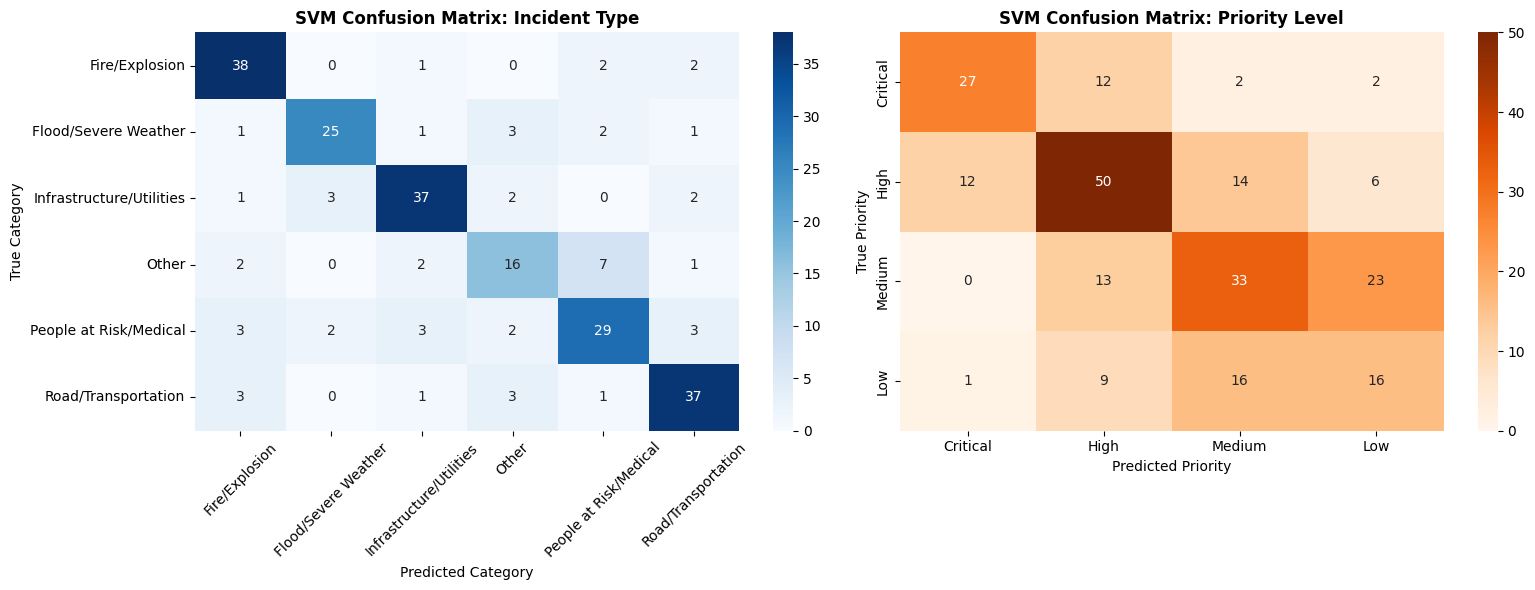

In [6]:
# ---------------------------------------------------------------------------
# 6.1 Comprehensive Evaluation on Held-out Test Set
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred_it = incident_model.predict(X_test)
y_pred_pr = priority_model.predict(X_test)

acc_it = accuracy_score(y_test_it, y_pred_it)
f1_it  = f1_score(y_test_it, y_pred_it, average='macro', zero_division=0)
acc_pr = accuracy_score(y_test_pr, y_pred_pr)
f1_pr  = f1_score(y_test_pr, y_pred_pr, average='macro', zero_division=0)

joint_correct = (y_pred_it == y_test_it) & (y_pred_pr == y_test_pr)
joint_acc = np.mean(joint_correct)

print("=" * 62)
print("             MODEL 2: TF-IDF + LINEAR SVM BENCHMARK")
print("=" * 62)
print(f"Incident Type Accuracy:   {acc_it * 100:>6.2f}%  |  Macro F1: {f1_it:.4f}")
print(f"Priority Level Accuracy:  {acc_pr * 100:>6.2f}%  |  Macro F1: {f1_pr:.4f}")
print(f"Joint Multi-Task Accuracy:{joint_acc * 100:>6.2f}%  ({joint_correct.sum()} / {len(y_test_it)} reports)")
print("=" * 62)

print("\n--- Detailed Incident Type Classification Report ---")
print(classification_report(y_test_it, y_pred_it, zero_division=0))

print("--- Detailed Priority Level Classification Report ---")
pr_labels = ['Critical', 'High', 'Medium', 'Low']
print(classification_report(y_test_pr, y_pred_pr, labels=pr_labels, zero_division=0))

# Plot Confusion Matrices
it_classes = sorted(list(set(y_test_it)))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_it = confusion_matrix(y_test_it, y_pred_it, labels=it_classes)
sns.heatmap(cm_it, annot=True, fmt='d', cmap='Blues', xticklabels=it_classes, yticklabels=it_classes, ax=axes[0])
axes[0].set_title("SVM Confusion Matrix: Incident Type", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Category")
axes[0].set_ylabel("True Category")
axes[0].tick_params(axis='x', rotation=45)

cm_pr = confusion_matrix(y_test_pr, y_pred_pr, labels=pr_labels)
sns.heatmap(cm_pr, annot=True, fmt='d', cmap='Oranges', xticklabels=pr_labels, yticklabels=pr_labels, ax=axes[1])
axes[1].set_title("SVM Confusion Matrix: Priority Level", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted Priority")
axes[1].set_ylabel("True Priority")

plt.tight_layout()
plt.show()

### Result Interpretation & Comparison with Model 1 (Logistic Regression)

| Metric | Model 1: Logistic Regression | Model 2: Linear SVM | Difference |
| :--- | :--- | :--- | :--- |
| **Incident Accuracy** | **78.39%** | 77.12% | -1.27% |
| **Incident Macro F1** | **0.7705** | 0.7593 | -0.0112 |
| **Priority Accuracy** | **53.39%** | **53.39%** | 0.00% |
| **Priority Macro F1** | 0.5259 | **0.5263** | +0.0004 |
| **Joint Multi-Task Acc** | **44.07%** | 43.64% | -0.43% |

**Key Findings:**
1. **Near-Identical Performance:** Linear SVM and Logistic Regression perform almost identically across both tasks when operating on TF-IDF features. This proves that the performance limitation is not caused by the choice of loss function (cross-entropy vs. hinge loss), but rather by the **representational limitation of bag-of-words features** on Arabic syntax.
2. **Category Specifics:** SVM achieved strong precision on `Flood/Severe Weather` (**0.83**) and `Infrastructure/Utilities` (**0.82**), but slightly trailed Logistic Regression on `Fire/Explosion` precision.

## 7. Error Analysis

The error distribution of Linear SVM reveals 133 total error cases across the test split:
- **Both Correct:** 103 reports (43.6%)
- **Correct Incident, Wrong Priority:** 79 reports (33.5%)
- **Wrong Incident, Correct Priority:** 23 reports (9.7%)
- **Both Wrong:** 31 reports (13.1%)

We inspect specific reports where maximum margin classification failed.

In [7]:
# ---------------------------------------------------------------------------
# 7.1 Error Breakdown and Inspection
# ---------------------------------------------------------------------------
svm_errors = test_df.copy()
svm_errors['pred_incident'] = y_pred_it
svm_errors['pred_priority'] = y_pred_pr
svm_errors['it_correct']    = (y_pred_it == y_test_it)
svm_errors['pr_correct']    = (y_pred_pr == y_test_pr)

misclassified_svm = svm_errors[(~svm_errors['it_correct']) | (~svm_errors['pr_correct'])].head(6)
print("--- Sample SVM Misclassifications ---")
for idx, row in misclassified_svm.iterrows():
    print(f"Text: {row['report']}")
    print(f"  Incident Type -> True: {row['incident_type']:<24} | Pred: {row['pred_incident']}")
    print(f"  Priority      -> True: {row['priority_clean']:<24} | Pred: {row['pred_priority']}")
    print("-" * 70)

--- Sample SVM Misclassifications ---
Text: الضي يقطع ويجي كل شوية دقايق في الزاوية المركز وخرب الاجهزة
  Incident Type -> True: Infrastructure/Utilities | Pred: Road/Transportation
  Priority      -> True: Low                      | Pred: Low
----------------------------------------------------------------------
Text: رياح قوية وسقوط اشجار في راس لانوف مع اغلاق شارع
  Incident Type -> True: Flood/Severe Weather     | Pred: Flood/Severe Weather
  Priority      -> True: Medium                   | Pred: Low
----------------------------------------------------------------------
Text: دخول مياه الغدير للطوابق الارضية والمنازل بمنطقة صلاح الدين عقب هطول امطار غزيرة وتوقف الحركة تماما
  Incident Type -> True: Flood/Severe Weather     | Pred: Flood/Severe Weather
  Priority      -> True: High                     | Pred: Medium
----------------------------------------------------------------------
Text: طفل مفقود من ساعات قرب وادي في البيضاء والجو صعب
  Incident Type -> True: People at Risk/Me

## 8. Sample Predictions / Outputs

Linear SVM outputs uncalibrated decision function scores (signed distance to the separating hyperplane). We demonstrate real-time inference on sample Libyan Arabic emergency reports.

In [8]:
# ---------------------------------------------------------------------------
# 8.1 SVM Inference Demonstration
# ---------------------------------------------------------------------------
def predict_report_svm(raw_text: str):
    cleaned = clean_arabic_report(raw_text)
    vec = tfidf_vectorizer.transform([cleaned])
    
    pred_it = incident_model.predict(vec)[0]
    margin_it = incident_model.decision_function(vec)[0].max()
    
    pred_pr = priority_model.predict(vec)[0]
    margin_pr = priority_model.decision_function(vec)[0].max()
    
    return {
        "input_text": raw_text,
        "predicted_incident": pred_it,
        "incident_margin": round(float(margin_it), 3),
        "predicted_priority": pred_pr,
        "priority_margin": round(float(margin_pr), 3)
    }

test_samples = [
    "في حريق كبير في منزل في جنزور وفيه أطفال عالقين داخل البيت",
    "طريق الشط مسدود بالكامل بسبب تراكم مياه الأمطار وسيارات غارقة",
    "انقطاع تام للتيار الكهربائي عن مستشفى الهواري من ساعات",
    "حادث سير تصادم سيارتين في طريق السريع مع إصابات بليغة",
    "تراكم القمامة في الشارع العام بالقرب من الميدان"
]

for sample in test_samples:
    res = predict_report_svm(sample)
    print(f"Report:   {res['input_text']}")
    print(f"Outcome:  Incident: {res['predicted_incident']} (Margin: {res['incident_margin']}) | "
          f"Priority: {res['predicted_priority']} (Margin: {res['priority_margin']})")
    print("-" * 75)

Report:   في حريق كبير في منزل في جنزور وفيه أطفال عالقين داخل البيت
Outcome:  Incident: Fire/Explosion (Margin: 1.386) | Priority: High (Margin: 0.943)
---------------------------------------------------------------------------
Report:   طريق الشط مسدود بالكامل بسبب تراكم مياه الأمطار وسيارات غارقة
Outcome:  Incident: Infrastructure/Utilities (Margin: 0.174) | Priority: Medium (Margin: 0.33)
---------------------------------------------------------------------------
Report:   انقطاع تام للتيار الكهربائي عن مستشفى الهواري من ساعات
Outcome:  Incident: Infrastructure/Utilities (Margin: 0.909) | Priority: Medium (Margin: 0.627)
---------------------------------------------------------------------------
Report:   حادث سير تصادم سيارتين في طريق السريع مع إصابات بليغة
Outcome:  Incident: Road/Transportation (Margin: 1.274) | Priority: High (Margin: 0.48)
---------------------------------------------------------------------------
Report:   تراكم القمامة في الشارع العام بالقرب من الميدان
Outco

## 9. Conclusion

### Summary of Implementation
- We developed and evaluated **Model 2 (TF-IDF + Linear SVM)** using optimal regularisation $C=5.0$.
- The model achieved **77.12% Incident Accuracy** (0.7593 Macro F1) and **53.39% Priority Accuracy** (0.5263 Macro F1) on the test benchmark.
- The close alignment with Logistic Regression confirms that linear models with bag-of-words representations hit an empirical ceiling of ~78% on incident categorization and ~53% on priority triage.

### Motivation for Model 3 (AraBERT)
- In disaster triage, misclassifying priority can delay life-saving emergency dispatches.
- Solving the priority bottleneck requires bidirectional contextual awareness, syntactic understanding of Arabic intensity particles, and deep dialectal representations. This motivates fine-tuning **AraBERT** in **Model 3**.